In [10]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
from hidten.tf import TFHMM
from hidten.tf.emitter import TFCategoricalEmitter, TFMVNormalEmitter

from learnMSA.util import visualize

In [17]:
hmm = TFHMM(states=2, heads=3)

hmm.transitioner.allow = [
    (0, 1), (1, 0), (0, 1, 1),
]
hmm.transitioner.initializer = np.exp([0, 0, 0, 1, 1, 1, 2])

hmm.add_emitter(TFCategoricalEmitter())
hmm.add_emitter(TFMVNormalEmitter())

hmm.emitter[0].initializer = np.exp([
    0, 1, 1, 0,
    0, 1, 1, 1,
    0, 1, 1, 2,
])
hmm.emitter[1].initializer = [
    -0.1, 0.9, 1.0, 0.5, 2.0, 0.2, 0.9, 1.1,
    -0.1, 0.9, 1.0, 0.5, 2.0, 0.2, 0.9, 1.1,
    -0.1, 0.9, 1.0, 0.5, 2.0, 0.2, 0.9, 1.1,
]

hmm.build(((2, ), (2, )))

In [18]:
hmm.emitter[0].matrix()

<tf.Tensor: shape=(3, 2, 2), dtype=float32, numpy=
array([[[0.26894143, 0.7310586 ],
        [0.7310586 , 0.26894143]],

       [[0.26894143, 0.7310586 ],
        [0.5       , 0.5       ]],

       [[0.26894143, 0.7310586 ],
        [0.26894143, 0.7310586 ]]], dtype=float32)>

In [19]:
hmm.emitter[1].matrix()

<tf.Tensor: shape=(3, 2, 4), dtype=float32, numpy=
array([[[-0.1       ,  0.9       ,  1.        ,  0.50000006],
        [ 2.        ,  0.2       ,  0.8999998 ,  1.1000001 ]],

       [[-0.1       ,  0.9       ,  1.        ,  0.50000006],
        [ 2.        ,  0.2       ,  0.8999998 ,  1.1000001 ]],

       [[-0.1       ,  0.9       ,  1.        ,  0.50000006],
        [ 2.        ,  0.2       ,  0.8999999 ,  1.0999999 ]]],
      dtype=float32)>

/home/felix/miniforge3/envs/learnMSAdev2/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'B' is not in color_dict. Using black.
  warnings.warn(str(Error))
/home/felix/miniforge3/envs/learnMSAdev2/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'B' is not in color_dict. Using black.
  warnings.warn(str(Error))


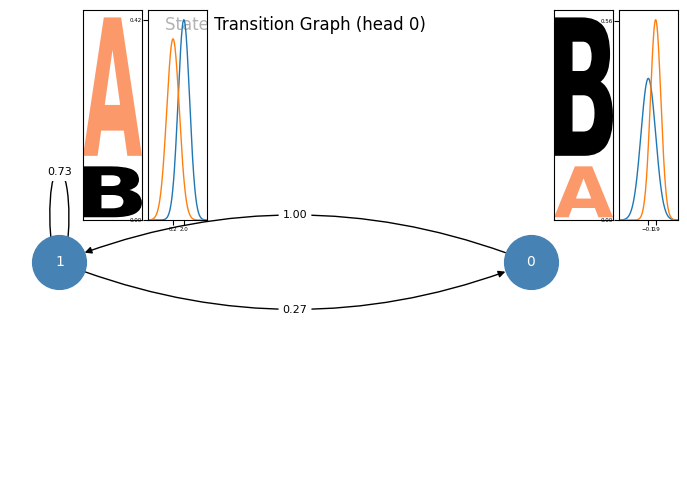

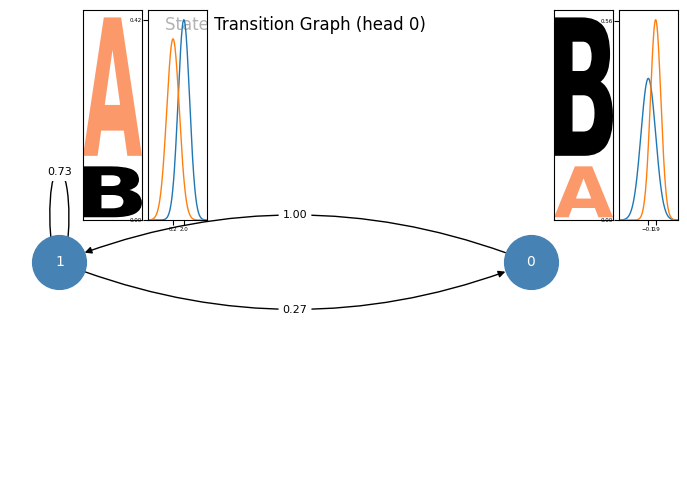

In [26]:

import imageio
import logomaker
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from hidten.hmm import HMM
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import norm


def plot_emissions(
    hmm: HMM,
    pos: dict,
    head: int = 0,
    emitter_index: int = 0,
    ax=None,
    inset_size: float | tuple[float, float] = 0.25,
    inset_offset: tuple[float, float] = (0.1, 0.05),
    inset_column: int = 0,
    alphabet: str = "ARNDCQEGHILKMFPSTWYVXUO",
    background: np.ndarray | None = None,
):
    """Plots small inset bar charts at each node showing the emission
    distribution for a given head and emitter.

    This function is designed to be called *after* ``plot_transition_graph``
    so that it overlays the emission insets on top of an existing graph plot.

    Args:
        hmm: The HMM whose emissions are visualised.
        G: The networkx graph that was drawn (used only for iterating nodes).
        pos: Node-position dict returned by the layout used when drawing ``G``
            (e.g. the value returned by :func:`plot_transition_graph`).
        head: Index of the HMM head to visualise (default: 0).
        emitter_index: Index of the emitter to visualise (default: 0).
        ax: The matplotlib Axes that the transition graph was drawn on.
            If *None* the current active axes is used.
        inset_size: Width and height of each inset axes expressed as a
            fraction of the data-coordinate span of the main axes. Either a
            single float (square) or a ``(width, height)`` tuple. The same
            size is used for all emitter types.
        inset_offset: (dx, dy) offset applied to each node position so the
            inset does not sit directly on top of the node label.
        inset_column: Integer column index used to stack multiple emitter
            insets side by side. Column ``k`` is shifted by
            ``k * (inset_width + margin)`` in the x direction relative to
            ``inset_offset``, where margin is 10 % of the inset width.
        alphabet: The alphabet used to create logo plots for categorical
            emitters. Ignored for non-categorical emitters.
        background: Background distribution of shape (A,) used to compute
            information content for categorical emitters. Must be provided
            when the emitter is categorical.

    Returns:
        The matplotlib Figure.
    """
    if ax is None:
        ax = plt.gca()
    fig = ax.get_figure()

    iw, ih = (inset_size, inset_size) if isinstance(inset_size, (int, float)) else inset_size
    margin = iw * 0.1
    col_shift = inset_column * (iw + margin)

    dx, dy = inset_offset
    dx = dx + col_shift

    # Find out the type of emitter to determine the type of plot
    if isinstance(hmm.emitter[emitter_index], TFCategoricalEmitter):
        if background is None:
            raise ValueError(
                "background must be provided for categorical emitters"
            )
        emitter = hmm.emitter[emitter_index]
        # B has shape (H, Q, A)
        B = emitter.matrix()
        try:
            B_np = B.numpy()
        except AttributeError:
            B_np = np.array(B)

        A = B_np.shape[2]
        chars = list(alphabet[:A])
        bg = np.asarray(background)

        for node, (x, y) in pos.items():
            probs = B_np[head, node, :]  # shape (A,)
            # Information content relative to background
            with np.errstate(divide='ignore', invalid='ignore'):
                ic = np.sum(np.where(probs > 0, probs * np.log2(probs / bg), 0.0))
            heights = ic * probs  # each character's contribution to IC

            df = pd.DataFrame([heights], columns=chars)

            axins = inset_axes(
                ax,
                width="100%",
                height="100%",
                bbox_to_anchor=(x + dx, y + dy, iw, ih),
                bbox_transform=ax.transData,
                loc="center",
                borderpad=0,
            )
            logomaker.Logo(df, ax=axins, color_scheme='skylign_protein', vpad=0.1, width=0.8)
            axins.set_xticks([])
            axins.set_yticks([])
            axins.patch.set_alpha(0.7)

    elif isinstance(hmm.emitter[emitter_index], TFMVNormalEmitter):
        emitter = hmm.emitter[emitter_index]
        # M has shape (H, Q, 2*D): first D entries are means, last D are variances
        M = emitter.matrix()
        try:
            M_np = M.numpy()
        except AttributeError:
            M_np = np.array(M)

        D = M_np.shape[2] // 2
        colors = plt.cm.tab10.colors

        for node, (x, y) in pos.items():
            means = M_np[head, node, :D]      # shape (D,)
            variances = M_np[head, node, D:]  # shape (D,)
            stds = np.sqrt(variances)

            # Shared x-range covering all dimensions
            x_min = min(means[d] - 4 * stds[d] for d in range(D))
            x_max = max(means[d] + 4 * stds[d] for d in range(D))
            xs = np.linspace(x_min, x_max, 200)

            # Compute all curves to set a consistent y-limit
            all_ys = [norm.pdf(xs, loc=means[d], scale=stds[d]) for d in range(D)]
            y_max = max(ys.max() for ys in all_ys)

            axins = inset_axes(
                ax,
                width="100%",
                height="100%",
                bbox_to_anchor=(x + dx, y + dy, iw, ih),
                bbox_transform=ax.transData,
                loc="center",
                borderpad=0,
            )
            for d in range(D):
                axins.plot(xs, all_ys[d], color=colors[d % len(colors)], linewidth=1.0)
            axins.set_xlim(x_min, x_max)
            axins.set_ylim(0, y_max * 1.05)
            axins.set_xticks([float(f"{m:.2g}") for m in means])
            axins.set_yticks([0, round(y_max, 2)])
            axins.tick_params(labelsize=4, pad=1)
            axins.patch.set_alpha(0.7)
    else:
        # Unknown emitter, keep sample plots for testing

        rng = np.random.default_rng(seed=42)
        emission_data = {
            i: rng.dirichlet(np.ones(4)) for i in range(2)
        }

        for node, (x, y) in pos.items():
            axins = inset_axes(
                ax,
                width="100%",
                height="100%",
                bbox_to_anchor=(x + dx, y + dy, iw, ih),
                bbox_transform=ax.transData,
                loc="center",
                borderpad=0,
            )
            data = emission_data[node]
            axins.bar(range(len(data)), data, color="steelblue", width=0.8)
            axins.set_xlim(-0.5, len(data) - 0.5)
            axins.set_ylim(0, 1)
            axins.set_xticks([])
            axins.set_yticks([])
            axins.patch.set_alpha(0.7)

    # Restore the main axes as the active axes so subsequent calls to
    # plt.gca() return the graph axes, not the last-created inset.
    fig.sca(ax)
    return fig

_,pos = visualize.plot_transition_graph(hmm, self_loop_connectionstyle="arc3,rad=0.4")
ax = plt.gca()
plot_emissions(hmm, pos=pos, emitter_index=0, inset_column=0, alphabet="AB", background=np.array([0.5, 0.5]), ax=ax)
plot_emissions(hmm, pos=pos, emitter_index=1, inset_column=1, ax=ax)


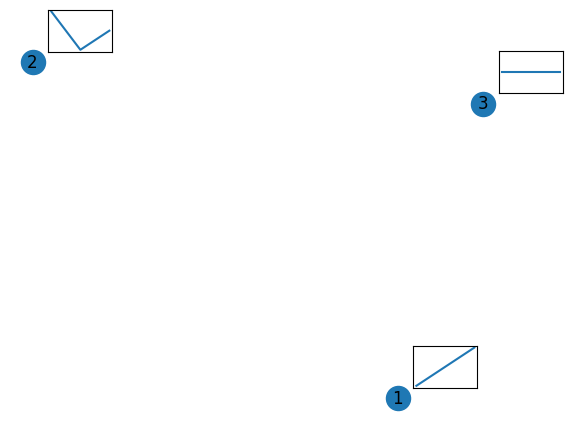

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

G = nx.Graph()
G.add_nodes_from([1, 2, 3])

node_data = {
    1: [1, 2, 3],
    2: [3, 1, 2],
    3: [2, 2, 2]
}

pos = nx.spring_layout(G)

fig, ax = plt.subplots()
nx.draw(G, pos, ax=ax, with_labels=True)

offset = (0.05, 0.05)

for node, (x, y) in pos.items():
    # Create inset anchored at data coordinates
    axins = inset_axes(
        ax,
        width="100%", height="100%",              # fill the bbox
        bbox_to_anchor=(x+offset[0], y+offset[1], 0.2, 0.2),         # (x, y, width, height) in data coords
        bbox_transform=ax.transData,
        loc='center',
        borderpad=0
    )

    # Apply a consistent offset (in points)
    axins.set_anchor('NW')  # optional anchor direction
    axins.plot(node_data[node])
    axins.set_xticks([])
    axins.set_yticks([])

plt.show()